# Generalized Linear Models (GLMs): 
includesdes linear regression, poisson regression, and  logistic regression ...
- Outcome variable: Accommodates response variables from different distributions, including binomial (for logistic regression), Poisson (for count data), and Gamma (for skewed data).
- Independence assumption: Requires that observations are independent.
- Model structure: It has three components:
    1. A random component: The probability distribution of the response variable (e.g., binomial).
    2. A systematic component: A linear combination of the predictor variables.
    3. A link function: A function that relates the linear predictor to the mean of the response variable (e.g., logit, log). 
        - a normal distribution typically uses an identity link ($g(\mu)=\mu$) 
        - while a binomial distribution often uses a logit link $g(\mu )=\ln \left(\       \frac{\mu }{1-\mu       } \right)$
- Generalized Linear Mixed Models (GLMMs) to include non-normal response variables.


- If you want to understand how features affect an outcome → use GLMM.
- If you want to predict outcomes accurately → use XGBoost.
- In some advanced workflows, people even use GLMM → residuals → XGBoost hybrid models (statistical + ML).

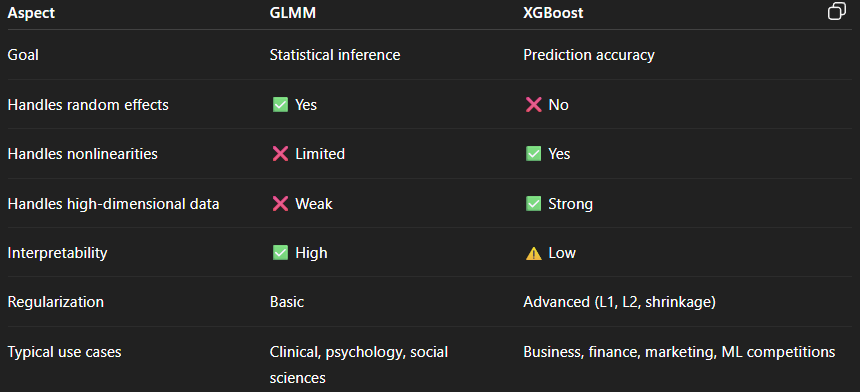

In [19]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Banking Marketing Campaigns

 more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed. So GLMM not GLM (logistics regression)

In [13]:
df = pd.read_csv("data/bank/bank-full.csv", sep=";")

In [ ]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
df = df.drop(columns=['duration'], errors='ignore')
categorical_vars = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month', 'poutcome', 'day'
]
for c in categorical_vars:
    df[c] = df[c].astype('category')

In [15]:
formula = (
    "y ~ age + balance + campaign + pdays + previous "
    "+ C(job) + C(marital) + C(education) + C(default) "
    "+ C(housing) + C(loan) + C(contact) + C(month) + C(poutcome)"
)

In [16]:
model = smf.glm(formula=formula, data=df, family=sm.families.Binomial())
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                  Generalized Linear Model Regression Results                  
===============================================================================
Dep. Variable:     ['y[no]', 'y[yes]']   No. Observations:                45211
Model:                             GLM   Df Residuals:                    45170
Model Family:                 Binomial   Df Model:                           40
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -13577.
Date:                 Tue, 28 Oct 2025   Deviance:                       27155.
Time:                         09:42:44   Pearson chi2:                 4.76e+04
No. Iterations:                      6   Pseudo R-squ. (CS):             0.1141
Covariance Type:             nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     1.2272      0.159      7.738      0.000       0.916       1.538
C(job)[T.blue-collar]         0.1159      0.065      1.783      0.075      -0.011       0.243
C(job)[T.entrepreneur]        0.1910      0.111      1.714      0.087      -0.027       0.409
C(job)[T.housemaid]           0.2982      0.120      2.485      0.013       0.063       0.533
C(job)[T.management]          0.0490      0.066      0.744      0.457      -0.080       0.178
C(job)[T.retired]            -0.4005      0.087     -4.626      0.000      -0.570      -0.231
C(job)[T.self-employed]       0.0884      0.099      0.890      0.374      -0.106       0.283
C(job)[T.services]            0.0762      0.075      1.021      0.307      -0.070       0.222
C(job)[T.student]            -0.3438      0.099     -3.459      0.001      -0.539      -0.149
C(job)[T.technician]          0.0590      0.062      0.952      0.341      -0.062       0.180
C(job)[T.unemployed]         -0.1152      0.098     -1.178      0.239      -0.307       0.077
C(job)[T.unknown]             0.1883      0.209      0.901      0.368      -0.221       0.598
C(marital)[T.married]         0.2017      0.052      3.890      0.000       0.100       0.303
C(marital)[T.single]         -0.0973      0.059     -1.642      0.101      -0.213       0.019
C(education)[T.secondary]    -0.1492      0.057     -2.623      0.009      -0.261      -0.038
C(education)[T.tertiary]     -0.3157      0.066     -4.760      0.000      -0.446      -0.186
C(education)[T.unknown]      -0.1961      0.093     -2.119      0.034      -0.378      -0.015
C(default)[T.yes]             0.1140      0.147      0.775      0.439      -0.174       0.403
C(housing)[T.yes]             0.5287      0.038     13.744      0.000       0.453       0.604
C(loan)[T.yes]                0.3984      0.053      7.492      0.000       0.294       0.503
C(contact)[T.telephone]       0.2449      0.065      3.756      0.000       0.117       0.373
C(contact)[T.unknown]         1.3283      0.063     21.067      0.000       1.205       1.452
C(month)[T.aug]               0.8450      0.069     12.167      0.000       0.709       0.981
C(month)[T.dec]              -0.5928      0.162     -3.668      0.000      -0.910      -0.276
C(month)[T.feb]               0.4135      0.075      5.490      0.000       0.266       0.561
C(month)[T.jan]               1.0876      0.106     10.243      0.000       0.880       1.296
C(month)[T.jul]               0.7000      0.068     10.272      0.000       0.566       0.834
C(month)[T.jun]              -0.1364      0.081     -1.687      0.092      -0.295       0.022
C(month)[T.mar]              -1.0906      0.111     -9.861      0.000      -1.307      -0.874
C(month)[T.may]               0.4805      0.064      7.560      

# Interpret Each Coefficient
The job dummies are differences relative to the reference job category (admin.)

```text
Job Category	Coef	p-value	Interpretation
blue-collar	+0.116	0.075	Slightly higher odds of subscribing than admin., but not significant (p > 0.05).
entrepreneur	+0.191	0.087	Somewhat higher odds, also not significant.
housemaid	+0.298	0.013	Significant — housemaids are more likely to subscribe than admin. workers.
management	+0.049	0.457	No significant difference.
```

# Convert Coefficients to Odds Ratios (≈e^coef)

```text
JobCategory	Coef	OddsRatio	| Meaning
housemaid	+0.298	1.35	        | 35 % higher odds of subscribing than admin.
retired	    −0.401	0.67	        | 33 % lower odds
student	    −0.344	0.71	        | 29 % lower odds
```

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

# 1. Load the dataset (Radon dataset included in statsmodels)
data = sm.datasets.radon.load_pandas().data
data['log_radon'] = np.log(data['activity'])
data['high_radon'] = (data['log_radon'] > 1).astype(int)

# 2. Fit the Binomial GLMM
# We model the high_radon outcome using floor as a fixed effect
# and including a random intercept for each county.
# 'county' is treated as a random effect, which accounts for the
# clustering of houses within counties.
glmm_model = smf.BinomialBayesMixedGLM.from_formula(
    'high_radon ~ 1 + floor',
    re_formula='1',  # A random intercept for each county
    vc_formula={'county': '0 + C(county)'}, # Use 'county' as grouping variable
    data=data
)

# Fit the model using variational Bayes approximation
glmm_results = glmm_model.fit_vb()

# 3. Print the model summary
print("\n--- Generalized Linear Mixed Model (Binomial) Results ---")
print(glmm_results.summary())

# Interpretation:
# The GLMM output includes both fixed and random effects.
# - The 'fixed effects' section shows the effect of the `floor` variable on the log-odds of high radon,
#   accounting for the non-independence of observations within the same county.
# - The 'random effects' section provides information about the variance introduced by the `county` groups.
#   This allows us to make more accurate inferences by properly modeling the dependency structure in the data.
